## Figures 4,7, and Table 3! 😄
pertaining to acoustic distance and WER section (Figure 4, 7, and Table 3 in our writeup)

The XLS‑R + DTW acoustic‑distance method follows Bartelds et al. (2022)

### Reproducing the XLS-R layer ablation (optional)

All figures below use **XLS-R layer 14**. To check that choice, recompute the per-word distances at other layers
and compare signal (cross-accent variance) to noise (within-American variance). The `distances` stage takes a
`--layer` flag, and a helper sweeps the full set:

```bash
# one layer, one category
python src/phonological_distance_pipeline.py --stage distances --layer 10 --category personal-introduction

# full ablation (layers 6, 8, 10, 12, 16 across all four categories) -> results/layer_ablation/
bash src/run_layer_ablation.sh
```

This reuses the existing Whisper timestamps, so only the XLS-R embedding + DTW step reruns (needs the audio and a GPU/MPS).

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi']  = 120
plt.rcParams['savefig.dpi'] = 150

# ── :) Global figure font sizes (used across all figures in this notebook) ──────
TITLE_FONT_SIZE = 25   # subplot titles, suptitles
AXIS_FONT_SIZE  = 20   # axis labels (x/y/supxlabel) and tick labels

ROOT = Path('..').resolve()
FIGS = ROOT / 'results' / 'figures'
FIGS.mkdir(exist_ok=True)

# ── XLS-R phonological distance files (duration-normalized, quality-filtered) ─────────
DIST_DIR = ROOT / 'results' / 'phone_distance_distances_only' / 'human'
PHON_CSVS = {
    'personal-introduction': DIST_DIR / 'word_distances_personal_intro.csv',
    'personal-commitment':   DIST_DIR / 'word_distances_commitment.csv',
    'financial-product':     DIST_DIR / 'word_distances_financial.csv',
    'client-disagreement':   DIST_DIR / 'word_distances_disagreement.csv',
}

# ── Hiring corpus CSVs (delivery scores from critical prompt only) ─────────────
CORPUS_PATHS = {
    'Gemini-2.5-Flash': ROOT / 'results' / 'hiring_corpus' / 'gemini-2.5-flash_hiring_corpus.csv',
    'Gemini-2.5-Pro':   ROOT / 'results' / 'hiring_corpus' / 'gemini-2.5-pro_hiring_corpus.csv',
    'Qwen':             ROOT / 'results' / 'hiring_corpus' / 'qwen_hiring_corpus.csv',
    'GPT-audio-1.5':    ROOT / 'results' / 'hiring_corpus' / 'gpt-audio-1.5_hiring_corpus.csv',
    'GPT-4o':           ROOT / 'results' / 'hiring_corpus' / 'gpt-4o-audio-preview_hiring_corpus.csv',
}

# ── Constants ────────────────────────────────────────────────────────────────────
PROPER_NOUN_EXCLUSIONS = {'ira', 'roth'}
SCRIPTED_CATS          = {'client-disagreement', 'financial-product',
                          'personal-commitment', 'personal-introduction'}

NAME_CORRECTIONS = {
    'speaker_09':             'speaker_09',
    'speaker_27': 'speaker_27',
    'orevaoghene_ahia':            'speaker_33',
}

ACCENT_ORDER  = ['Nigerian', 'Chinese', 'Indian', 'British', 'American']
ACCENT_COLORS = {
    'American': '#9B72CF',  # purple (cool)
    'British':  '#0072B2',  # deep blue (cool)
    'Chinese':  '#F0A500',  # golden orange (warm)
    'Indian':   '#009E73',  # bluish green (cool)
    'Nigerian': '#D55E00',  # vermilion (warm)
}

# Models for Figure 5 (human corpus) — 4 panels
HUMAN_MODELS  = ['Gemini-2.5-Flash', 'Gemini-2.5-Pro', 'Qwen', 'GPT-audio-1.5']
# Models for Figure 5.1 (synthetic) — kept separate
STABLE_MODELS = ['Gemini-2.5-Flash', 'Qwen', 'GPT-4o']

## Load XLS-R distances

Loads per-word duration-normalized DTW distances from the four scripted categories.
Quality filter: words with ≥2 American reference tokens, SNR ≥ 1.0, mean duration ≥ 0.20s.
Distances are normalized by `max(speaker_dur, american_mean_dur) × FRAME_RATE`.

In [2]:
def _load_category(dist_csv):
    """Load quality-filtered normalized distances for one script category.
    norm_dist (duration-normalized DTW) and am_dur are pre-computed in the CSV.
    """
    if not dist_csv.exists():
        print(f'  WARNING: missing {dist_csv}')
        return None
    df = pd.read_csv(dist_csv)
    # Keep words with ≥2 American reference tokens
    am_nref  = df[df['accent'] == 'American'].groupby('word')['n_ref'].first()
    reliable = set(am_nref[am_nref >= 2].index)
    df1 = df[df['word'].isin(reliable)].copy()
    # SNR filter: cross-accent std / within-American std ≥ 1.0
    wacc   = (df1.groupby(['word', 'accent'])['distance'].mean().reset_index()
              .pivot(index='word', columns='accent', values='distance'))
    within = df1[df1['accent'] == 'American'].groupby('word')['distance'].std()
    cross  = wacc.drop(columns='American', errors='ignore').std(axis=1)
    snr    = (cross / within).replace([np.inf, -np.inf], np.nan)
    # Duration filter: mean word duration across ALL occurrences, ALL speakers ≥ 0.20s
    # (all_dur pre-computed from all TSV occurrences, matching original filter)
    all_dur = df1.groupby('word')['all_dur'].first()
    quality = (set(snr[(snr >= 1.0) &
                       (all_dur.reindex(snr.index).fillna(0) >= 0.20)].index)
               - PROPER_NOUN_EXCLUSIONS)
    df_q = df1[df1['word'].isin(quality)].copy()
    return df_q if not df_q.empty else None


# Load all 4 script categories
all_parts = []
for cat_key, dist_csv_path in PHON_CSVS.items():
    df_r = _load_category(dist_csv_path)
    if df_r is not None:
        df_r = df_r.copy()
        df_r['category'] = cat_key
        all_parts.append(df_r)
        print(f"  {cat_key}: {df_r['speaker_id'].nunique()} speakers, "
              f"{df_r['word'].nunique()} quality words")
    else:
        print(f'  {cat_key}: NOT FOUND')

all_rate = pd.concat(all_parts, ignore_index=True)

# Per-speaker mean normalized DTW distance, pooled across all 4 scripts
sp_dtw = (all_rate
          .groupby(['speaker_id', 'accent'])['norm_dist']
          .mean().reset_index()
          .rename(columns={'norm_dist': 'mean_norm_dist', 'speaker_id': 'speaker_key'}))
print(f'\nPer-speaker distances: {len(sp_dtw)} speakers')


def _sp_scores(path):
    """Load per-speaker mean delivery score (critical prompt, scripted categories)."""
    df = pd.read_csv(path)
    df['_rating'] = df['model_output'].apply(
        lambda s: next(
            (int(m) for m in reversed(re.findall(r'\d+', str(s))) if 1 <= int(m) <= 7),
            None,
        )
    )
    sub = df[(df['script_type'] == 'delivery') &
             (df['prompt_type'] == 'critical') &
             (df['category'].isin(SCRIPTED_CATS))].copy()
    sub['speaker_key'] = sub['speaker_name_from_file'].str.replace(' ', '_', regex=False)
    sub['speaker_key'] = sub['speaker_key'].replace(NAME_CORRECTIONS)
    return (sub.groupby('speaker_key')['_rating']
            .mean().reset_index()
            .rename(columns={'_rating': 'delivery'}))


# Merge acoustic distances with delivery scores for each stable model
MERGED = {}
for model, path in CORPUS_PATHS.items():
    scores = _sp_scores(path)
    m = sp_dtw.merge(scores, on='speaker_key', how='inner')
    MERGED[model] = m
    rho, p = stats.spearmanr(m['mean_norm_dist'], m['delivery'])
    print(f'  {model}: n={len(m)}, Spearman ρ={rho:.3f}, p={p:.4f}')


  personal-introduction: 52 speakers, 24 quality words
  personal-commitment: 52 speakers, 24 quality words
  financial-product: 52 speakers, 31 quality words
  client-disagreement: 52 speakers, 25 quality words

Per-speaker distances: 52 speakers
  Gemini-2.5-Flash: n=52, Spearman ρ=-0.348, p=0.0115
  Gemini-2.5-Pro: n=52, Spearman ρ=-0.497, p=0.0002
  Qwen: n=52, Spearman ρ=-0.662, p=0.0000
  GPT-audio-1.5: n=52, Spearman ρ=-0.563, p=0.0000
  GPT-4o: n=52, Spearman ρ=-0.435, p=0.0013


## Figure 4 — HUMAN Delivery score vs. XLS-R acoustic distance

Each point = one speaker. Diamonds = accent-group centroid. 

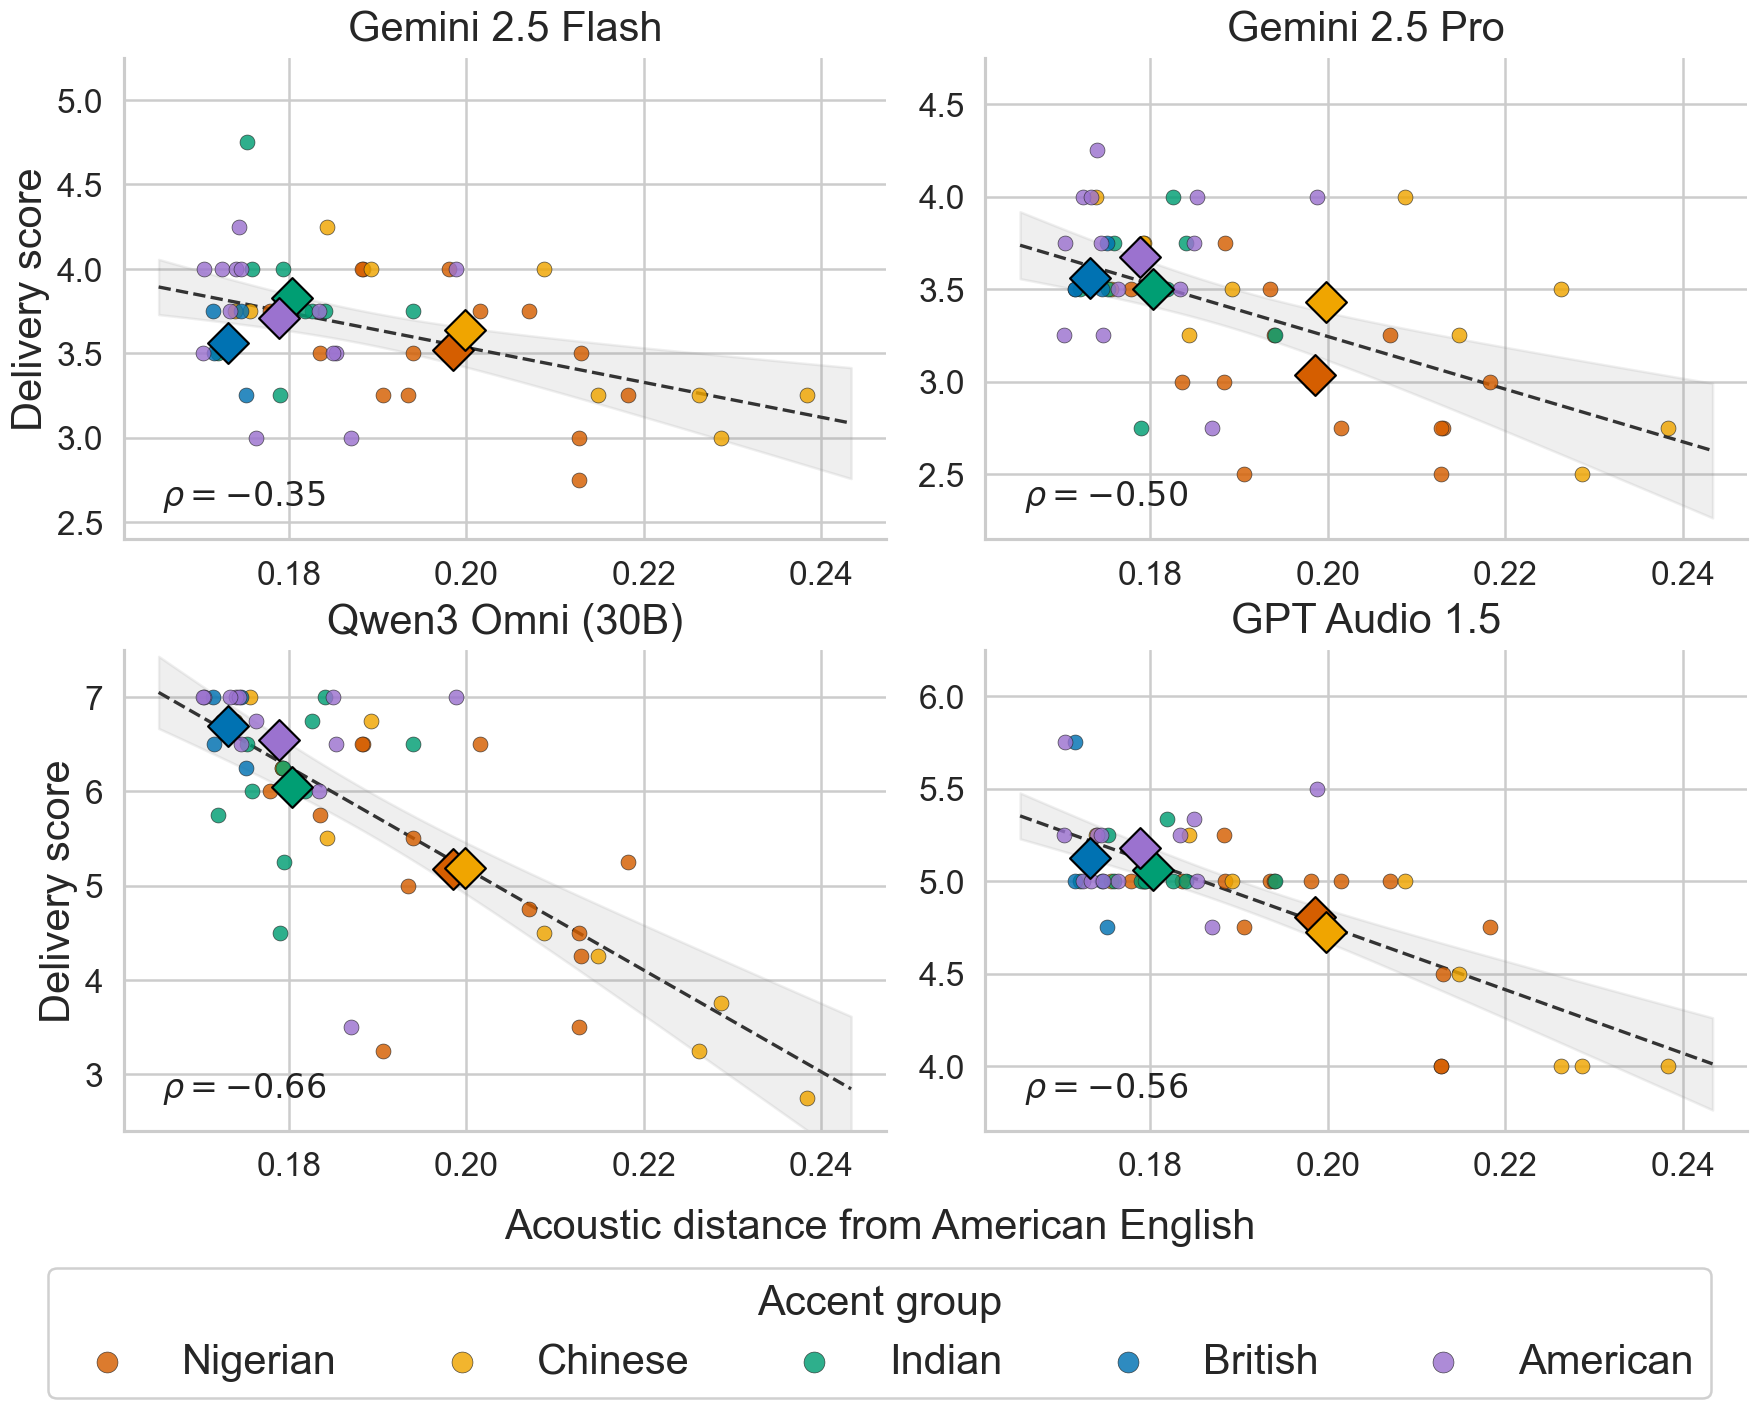

Saved: fig5_xlsr_correlation.pdf


In [3]:
MODEL_DISPLAY = {
    'Gemini-2.5-Flash': 'Gemini 2.5 Flash',
    'Gemini-2.5-Pro':   'Gemini 2.5 Pro',
    'Qwen':             'Qwen3 Omni (30B)',
    'GPT-audio-1.5':    'GPT Audio 1.5',
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

legend_handles = None
for col, model in enumerate(HUMAN_MODELS):
    ax   = axes[col // 2, col % 2]
    row  = col // 2
    colx = col % 2
    m  = MERGED[model]
    x  = m['mean_norm_dist'].values
    y  = m['delivery'].values

    slope, intercept, _, _, _ = stats.linregress(x, y)
    xl   = np.linspace(x.min() - 0.005, x.max() + 0.005, 200)
    yhat = slope * xl + intercept
    n    = len(x)
    res_std = np.sqrt(np.sum((y - (slope * x + intercept)) ** 2) / (n - 2))
    se  = res_std * np.sqrt(1 / n + (xl - x.mean()) ** 2 / np.sum((x - x.mean()) ** 2))
    t95 = stats.t.ppf(0.975, df=n - 2)

    ax.fill_between(xl, yhat - t95 * se, yhat + t95 * se,
                    color='#888', alpha=0.13, zorder=1)
    ax.plot(xl, yhat, color='#333', lw=2.0, ls='--', zorder=2)

    handles = []
    for acc in ACCENT_ORDER:
        sub = m[m['accent'] == acc]
        h = ax.scatter(sub['mean_norm_dist'], sub['delivery'],
                       color=ACCENT_COLORS[acc], s=80, alpha=0.82,
                       edgecolors='#222', linewidths=0.4, label=acc, zorder=4)
        handles.append(h)
    for acc in ACCENT_ORDER:
        sub = m[m['accent'] == acc]
        if len(sub):
            ax.scatter(sub['mean_norm_dist'].mean(), sub['delivery'].mean(),
                       color=ACCENT_COLORS[acc], s=300, marker='D',
                       edgecolors='black', linewidths=1.3, zorder=5)

    if legend_handles is None:
        legend_handles = handles

    rho, _ = stats.spearmanr(x, y)
    ax.text(0.05, 0.07, f'$\\rho = {rho:.2f}$',
            transform=ax.transAxes, fontsize=AXIS_FONT_SIZE, color='#222')

    # y-axis label only on left column; x-axis handled by fig.supxlabel
    if colx == 0:
        ax.set_ylabel('Delivery score', fontsize=TITLE_FONT_SIZE)
    else:
        ax.set_ylabel('')

    ax.set_title(MODEL_DISPLAY[model], fontsize=TITLE_FONT_SIZE, pad=10)
    ax.tick_params(labelsize=AXIS_FONT_SIZE)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(max(1.0, y.min() - 0.35), y.max() + .5)

fig.tight_layout()
fig.subplots_adjust(bottom=0.20)
fig.supxlabel('Acoustic distance from American English', fontsize=TITLE_FONT_SIZE, y=0.12)
fig.legend(handles=legend_handles, labels=ACCENT_ORDER,
           title='Accent group', fontsize=TITLE_FONT_SIZE, title_fontsize=TITLE_FONT_SIZE,
           loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, 0.0), framealpha=0.92, markerscale=1.4)

fig.savefig(FIGS / 'fig5_xlsr_correlation.pdf', bbox_inches='tight')
plt.show()
print('Saved: fig5_xlsr_correlation.pdf')

## Figure 4.1 — SYNTHETIC Delivery score vs. XLS-R acoustic distance


In [4]:
import glob as _glob

SYNTH_DIST_DIR = ROOT / 'results' / 'phone_distance_distances_only' / 'synthetic'
SYNTH_PHON_CSVS = {
    'personal-introduction': SYNTH_DIST_DIR / 'word_distances_personal_intro.csv',
    'personal-commitment':   SYNTH_DIST_DIR / 'word_distances_commitment.csv',
    'financial-product':     SYNTH_DIST_DIR / 'word_distances_financial.csv',
    'client-disagreement':   SYNTH_DIST_DIR / 'word_distances_disagreement.csv',
}

SYNTH_CORPUS_DIR  = ROOT / 'results' / 'hiring_synthetic'
IMMIGRATION_DIR   = ROOT / 'results' / 'immigration'
EDUCATION_DIR     = ROOT / 'results' / 'education'

# Critical delivery paths per model — hiring, immigration, education (classroom + conference)
SYNTH_ALL_PATHS = {
    'Gemini-2.5-Flash': {
        'hiring':      SYNTH_CORPUS_DIR  / 'gemini-2.5-flash_hiring_synthetic_critical.csv',
        'immigration': IMMIGRATION_DIR   / 'gemini-2.5-flash_immigration_critical.csv',
        'education':   sorted(_glob.glob(str(EDUCATION_DIR / 'gemini-2.5-flash_education_critical_*.csv'))),
    },
    'Gemini-2.5-Pro': {
        'hiring':      SYNTH_CORPUS_DIR  / 'gemini-2.5-pro_hiring_synthetic_critical.csv',
        'immigration': IMMIGRATION_DIR   / 'gemini-2.5-pro_immigration_critical.csv',
        'education':   sorted(_glob.glob(str(EDUCATION_DIR / 'gemini-2.5-pro_education_critical_*.csv'))),
    },
    'Qwen': {
        'hiring':      SYNTH_CORPUS_DIR  / 'qwen_hiring_synthetic_critical.csv',
        'immigration': IMMIGRATION_DIR   / 'qwen_immigration_critical.csv',
        'education':   sorted(_glob.glob(str(EDUCATION_DIR / 'qwen_education_critical_*.csv'))),
    },
    'GPT-audio-1.5': {
        'hiring':      SYNTH_CORPUS_DIR  / 'gpt-audio-1.5_hiring_synthetic_critical.csv',
        'immigration': IMMIGRATION_DIR   / 'gpt-audio-1.5_immigration_critical.csv',
        'education':   sorted(_glob.glob(str(EDUCATION_DIR / 'gpt-audio-1.5_education_critical_*.csv'))),
    },
}

SYNTH_SCRIPTED_CATS = {
    'Personal-Introduction', 'Personal-Commitment',
    'Financial-Product', 'Client-Disagreement',
}
SYNTH_NEW_MODELS = ['Gemini-2.5-Flash', 'Gemini-2.5-Pro', 'Qwen', 'GPT-audio-1.5']

# ololade is 'ololade' in distance files but 'ololade_awaye' in immigration/education
SYNTH_NAME_FIX = {'ololade_awaye': 'ololade'}


  personal-introduction: 30 speakers, 30 quality words
  personal-commitment: 30 speakers, 28 quality words
  financial-product: 30 speakers, 24 quality words
  client-disagreement: 30 speakers, 35 quality words

Per-speaker distances: 30 speakers

Domain rho per model:
  Gemini-2.5-Flash      Hiring       (synthetic)  rho=-0.453  p=0.0120  n=30
  Gemini-2.5-Flash      Immigration  (synthetic)  rho=-0.513  p=0.0038  n=30
  Gemini-2.5-Flash      Education    (synthetic)  rho=-0.568  p=0.0011  n=30
  -> most biased: Education  rho=-0.568

  Gemini-2.5-Pro        Hiring       (synthetic)  rho=-0.723  p=0.0000  n=30
  Gemini-2.5-Pro        Immigration  (synthetic)  rho=-0.534  p=0.0024  n=30
  Gemini-2.5-Pro        Education    (synthetic)  rho=-0.706  p=0.0000  n=30
  -> most biased: Hiring  rho=-0.723

  Qwen                  Hiring       (synthetic)  rho=-0.390  p=0.0332  n=30
  Qwen                  Immigration  (synthetic)  rho=+0.433  p=0.0170  n=30
  Qwen                  Education 

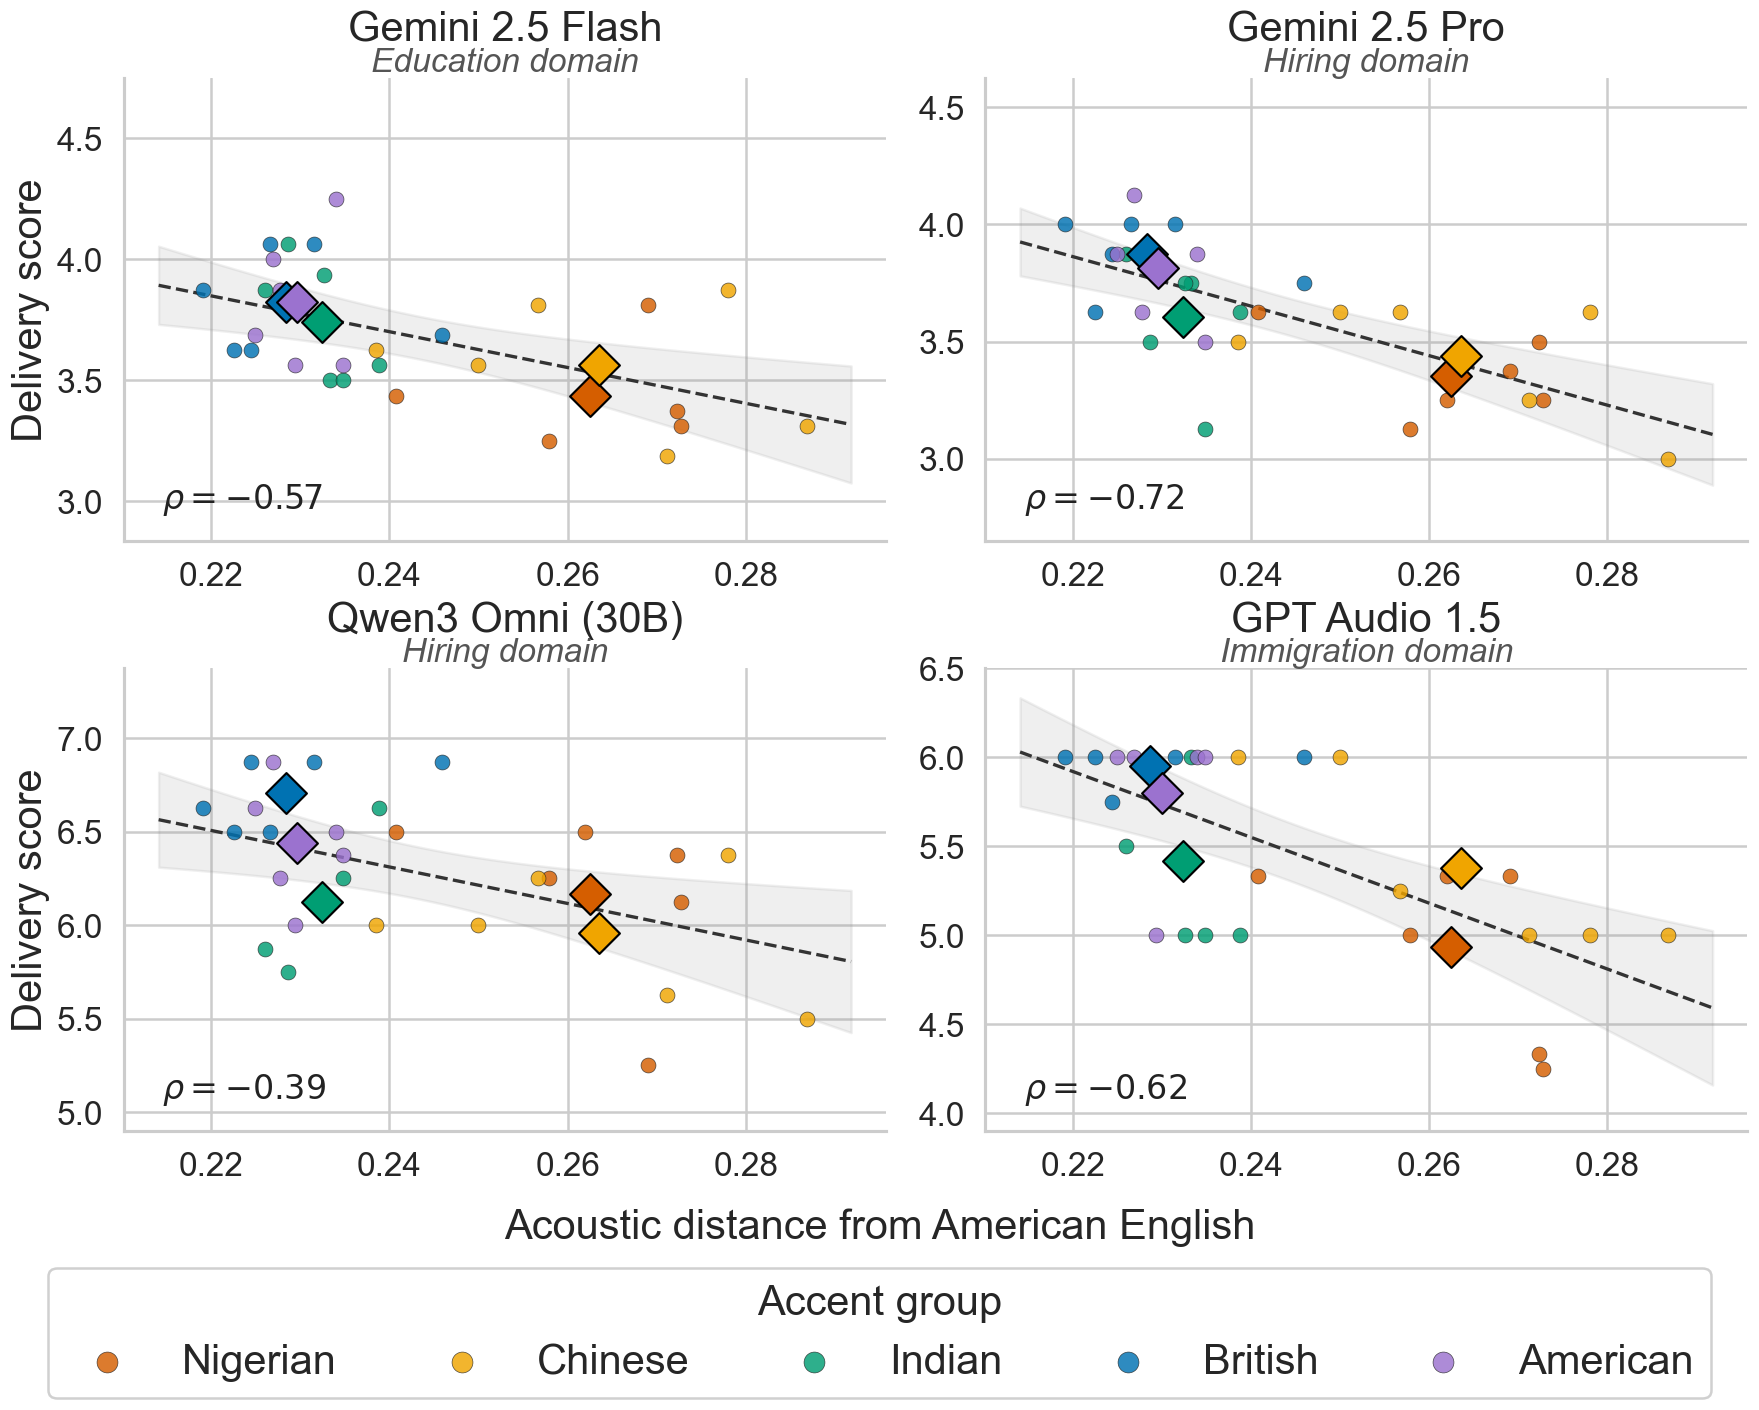

Saved: fig5p1_xlsr_correlation_synthetic.pdf


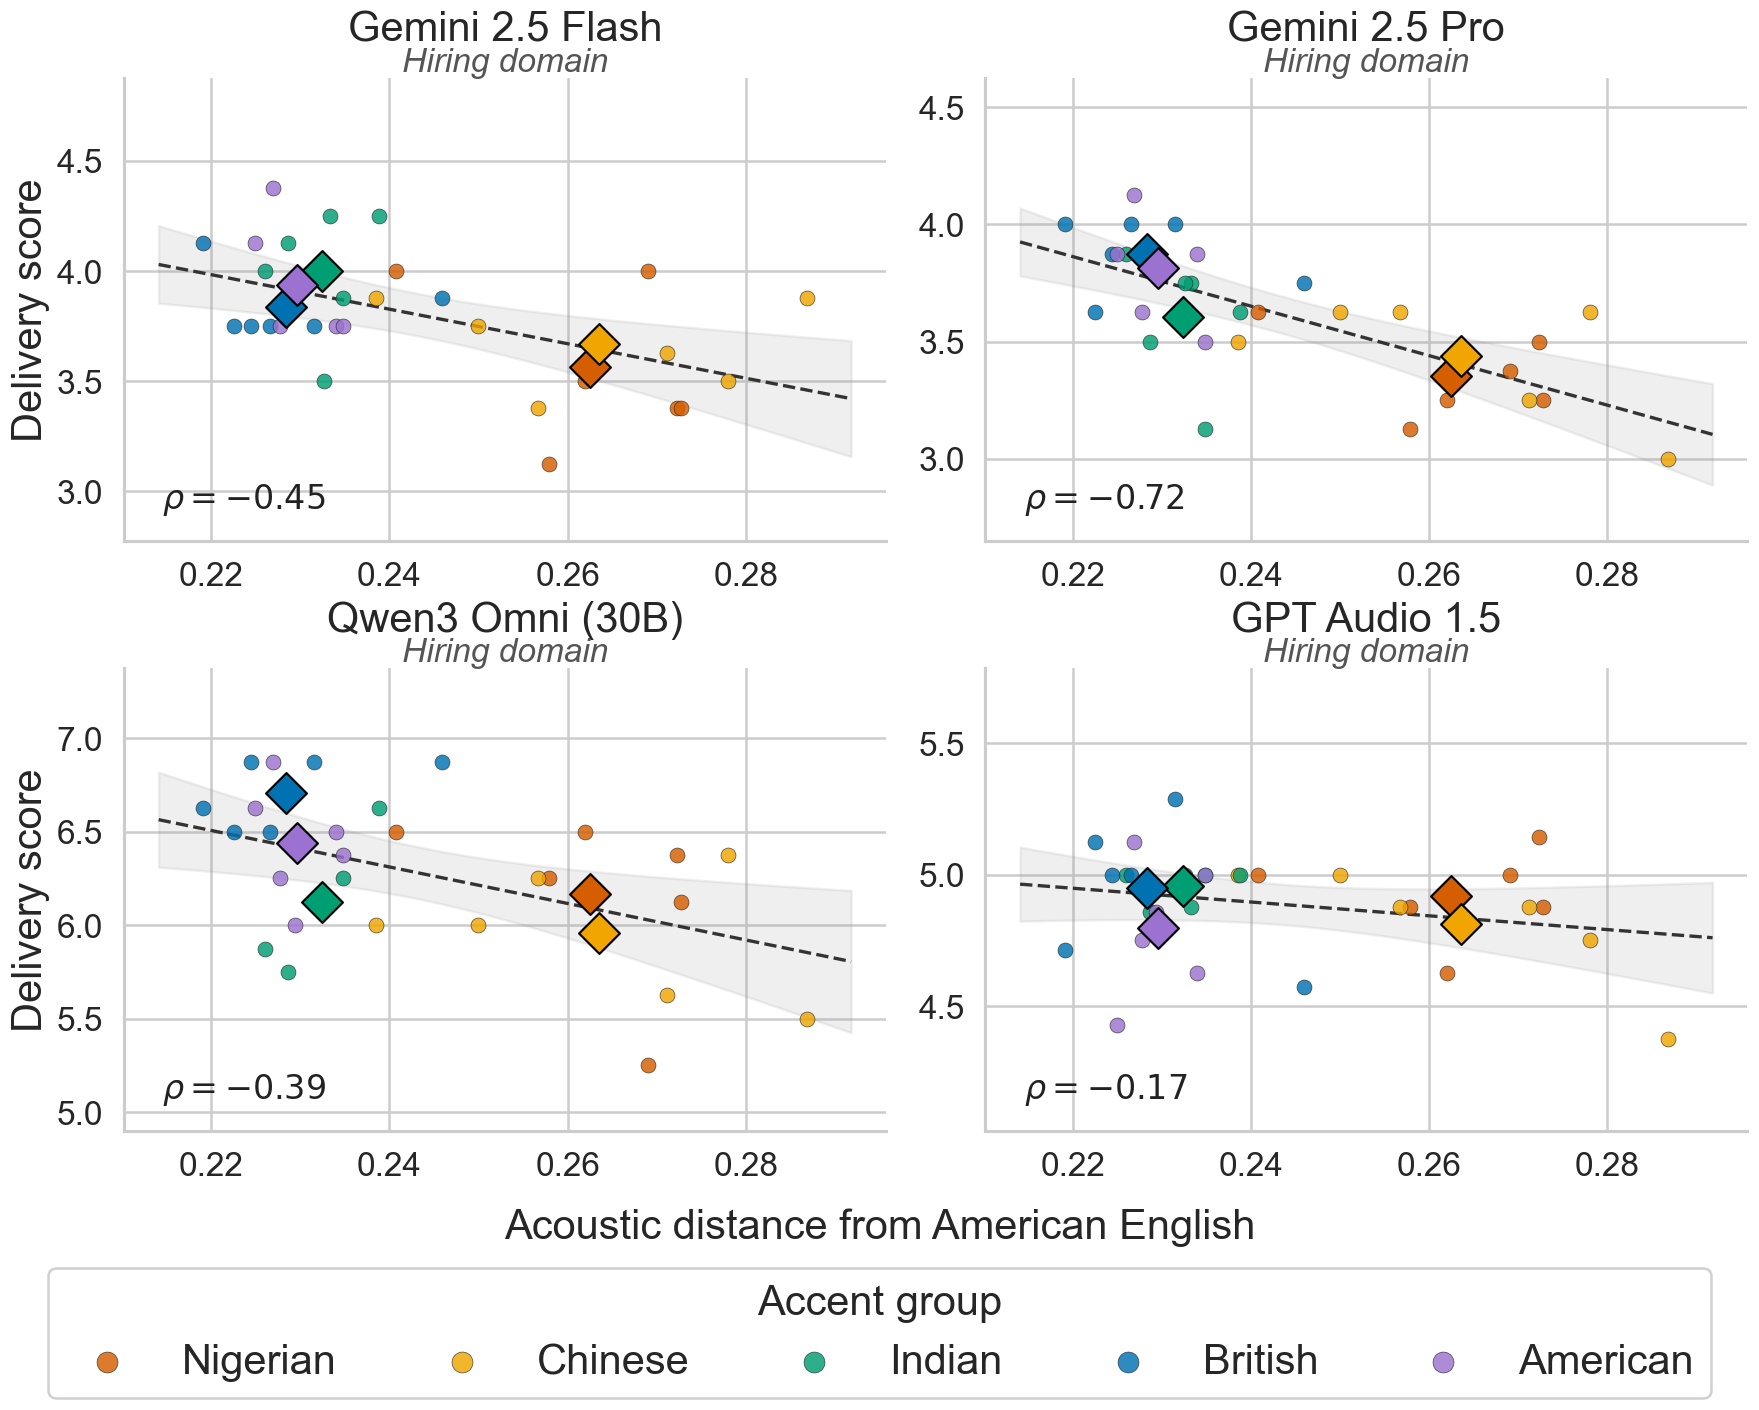

Saved: fig5p2_xlsr_correlation_synthetic_hiring.pdf


In [5]:
def _extract_rating(s, lo=1, hi=7):
    return next((int(m) for m in reversed(re.findall(r'\d+', str(s))) if lo <= int(m) <= hi), None)


def _sp_scores_synth_hiring(hiring_path):
    """Per-speaker mean delivery score from hiring corpus only."""
    df = pd.read_csv(hiring_path)
    df['_r'] = df['model_output'].apply(_extract_rating)
    sub = df[(df['script_type'] == 'delivery') & (df['category'].isin(SYNTH_SCRIPTED_CATS))].copy()
    sub['speaker_key'] = sub['speaker_name'].str.lower().str.replace(' ', '_', regex=False)
    return (sub.dropna(subset=['_r'])
            .groupby('speaker_key')['_r']
            .mean().reset_index()
            .rename(columns={'_r': 'delivery'}))


def _sp_scores_synth_immigration(imm_path):
    """Per-speaker mean delivery score from immigration corpus."""
    df = pd.read_csv(imm_path)
    df['_r'] = df['model_output'].apply(_extract_rating)
    sub = df[df['script_type'] == 'delivery'].copy()
    sub['speaker_key'] = sub['speaker_name'].str.lower().str.replace(' ', '_', regex=False)
    sub['speaker_key'] = sub['speaker_key'].replace(SYNTH_NAME_FIX)
    return (sub.dropna(subset=['_r'])
            .groupby('speaker_key')['_r']
            .mean().reset_index()
            .rename(columns={'_r': 'delivery'}))


def _sp_scores_synth_education(edu_paths):
    """Per-speaker mean delivery score from education corpus (classroom + conference)."""
    parts = []
    for fpath in edu_paths:
        df = pd.read_csv(fpath)
        df['_r'] = df['model_output'].apply(_extract_rating)
        sub = df[df['script_type'] == 'delivery'].copy()
        sub['speaker_key'] = sub['speaker_name'].str.lower().str.replace(' ', '_', regex=False)
        parts.append(sub[['speaker_key', '_r']])
    all_df = pd.concat(parts, ignore_index=True)
    all_df['speaker_key'] = all_df['speaker_key'].replace(SYNTH_NAME_FIX)
    return (all_df.dropna(subset=['_r'])
            .groupby('speaker_key')['_r']
            .mean().reset_index()
            .rename(columns={'_r': 'delivery'}))


# -- Load synthetic XLS-R distances -------------------------------------------
synth_parts = []
for cat_key, dist_csv_path in SYNTH_PHON_CSVS.items():
    df_r = _load_category(dist_csv_path)
    if df_r is not None:
        df_r = df_r.copy()
        df_r['category'] = cat_key
        synth_parts.append(df_r)
        print(f"  {cat_key}: {df_r['speaker_id'].nunique()} speakers, "
              f"{df_r['word'].nunique()} quality words")
    else:
        print(f'  {cat_key}: NOT FOUND')

synth_all = pd.concat(synth_parts, ignore_index=True)
synth_sp_dtw = (synth_all
                .groupby(['speaker_id', 'accent'])['norm_dist']
                .mean().reset_index()
                .rename(columns={'norm_dist': 'mean_norm_dist', 'speaker_id': 'speaker_key'}))
print(f'\nPer-speaker distances: {len(synth_sp_dtw)} speakers')

# -- For each model, find the most-biased domain (lowest Spearman rho) --------
DOMAIN_SCORE_FNS = {
    'Hiring':      lambda paths: _sp_scores_synth_hiring(paths['hiring']),
    'Immigration': lambda paths: _sp_scores_synth_immigration(paths['immigration']),
    'Education':   lambda paths: _sp_scores_synth_education(paths['education']),
}

SYNTH_MERGED_MOST_BIASED = {}
print('\nDomain rho per model:')
for model in SYNTH_NEW_MODELS:
    best_rho, best_domain, best_merged = None, None, None
    for domain, score_fn in DOMAIN_SCORE_FNS.items():
        scores = score_fn(SYNTH_ALL_PATHS[model])
        m = synth_sp_dtw.merge(scores, on='speaker_key', how='inner')
        if len(m) < 3:
            continue
        rho, p = stats.spearmanr(m['mean_norm_dist'], m['delivery'])
        print(f'  {model:20s}  {domain:12s} (synthetic)  rho={rho:+.3f}  p={p:.4f}  n={len(m)}')
        if best_rho is None or rho < best_rho:
            best_rho, best_domain, best_merged = rho, domain, m
    SYNTH_MERGED_MOST_BIASED[model] = (best_merged, best_domain)
    print(f'  -> most biased: {best_domain}  rho={best_rho:+.3f}\n')

# -- Hiring-only (for Figure 5.2) ---------------------------------------------
SYNTH_MERGED_HIRING = {}
for model in SYNTH_NEW_MODELS:
    scores = _sp_scores_synth_hiring(SYNTH_ALL_PATHS[model]['hiring'])
    m = synth_sp_dtw.merge(scores, on='speaker_key', how='inner')
    SYNTH_MERGED_HIRING[model] = m
    rho, p = stats.spearmanr(m['mean_norm_dist'], m['delivery'])
    print(f'  {model} (hiring only): n={len(m)}, Spearman rho={rho:.3f}, p={p:.4f}')


SYNTH_MODEL_DISPLAY = {
    'Gemini-2.5-Flash': 'Gemini 2.5 Flash',
    'Gemini-2.5-Pro':   'Gemini 2.5 Pro',
    'Qwen':             'Qwen3 Omni (30B)',
    'GPT-audio-1.5':    'GPT Audio 1.5',
}

def _plot_synth_fig(merged_dict, save_path, domain_labels=None):
    """
    merged_dict values may be plain DataFrames or (DataFrame, domain_label) tuples.
    domain_labels: optional dict model -> str shown as italic subtitle under model name.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    legend_handles_s = None

    for col, model in enumerate(SYNTH_NEW_MODELS):
        row  = col // 2
        colx = col % 2
        ax   = axes[row, colx]

        val = merged_dict[model]
        if isinstance(val, tuple):
            m, dlabel = val
        else:
            m = val
            dlabel = domain_labels[model] if domain_labels else None

        x = m['mean_norm_dist'].values
        y = m['delivery'].values

        slope, intercept, _, _, _ = stats.linregress(x, y)
        xl   = np.linspace(x.min() - 0.005, x.max() + 0.005, 200)
        yhat = slope * xl + intercept
        n    = len(x)
        res_std = np.sqrt(np.sum((y - (slope * x + intercept)) ** 2) / (n - 2))
        se  = res_std * np.sqrt(1 / n + (xl - x.mean()) ** 2 / np.sum((x - x.mean()) ** 2))
        t95 = stats.t.ppf(0.975, df=n - 2)

        ax.fill_between(xl, yhat - t95 * se, yhat + t95 * se,
                        color='#888', alpha=0.13, zorder=1)
        ax.plot(xl, yhat, color='#333', lw=2.0, ls='--', zorder=2)

        handles = []
        for acc in ACCENT_ORDER:
            sub = m[m['accent'] == acc]
            h = ax.scatter(sub['mean_norm_dist'], sub['delivery'],
                           color=ACCENT_COLORS[acc], s=80, alpha=0.82,
                           edgecolors='#222', linewidths=0.4, label=acc, zorder=4)
            handles.append(h)
        for acc in ACCENT_ORDER:
            sub = m[m['accent'] == acc]
            if len(sub):
                ax.scatter(sub['mean_norm_dist'].mean(), sub['delivery'].mean(),
                           color=ACCENT_COLORS[acc], s=300, marker='D',
                           edgecolors='black', linewidths=1.3, zorder=5)

        if legend_handles_s is None:
            legend_handles_s = handles

        rho, _ = stats.spearmanr(x, y)
        ax.text(0.05, 0.07, f'$\\rho = {rho:.2f}$',
                transform=ax.transAxes, fontsize=AXIS_FONT_SIZE, color='#222')

        # y-axis label only on left column; x-axis handled by fig.supxlabel
        if colx == 0:
            ax.set_ylabel('Delivery score', fontsize=TITLE_FONT_SIZE)
        else:
            ax.set_ylabel('')

        ax.set_title(SYNTH_MODEL_DISPLAY[model], fontsize=TITLE_FONT_SIZE, pad=22)
        if dlabel:
            ax.text(0.5, 1.00, f'{dlabel} domain',
                    transform=ax.transAxes, ha='center', va='bottom',
                    fontsize=AXIS_FONT_SIZE, style='italic', color='#555')

        ax.tick_params(labelsize=AXIS_FONT_SIZE)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_ylim(max(1.0, y.min() - 0.35), y.max() + 0.5)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.20)
    fig.supxlabel('Acoustic distance from American English', fontsize=TITLE_FONT_SIZE, y=0.12)
    fig.legend(handles=legend_handles_s, labels=ACCENT_ORDER,
               title='Accent group', fontsize=TITLE_FONT_SIZE, title_fontsize=TITLE_FONT_SIZE,
               loc='lower center', ncol=5,
               bbox_to_anchor=(0.5, 0.0), framealpha=0.92, markerscale=1.4)
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path.name}')


# -- Figure 5.1: most-biased domain per model ---------------------------------
_plot_synth_fig(SYNTH_MERGED_MOST_BIASED, FIGS / 'fig5p1_xlsr_correlation_synthetic.pdf')

# -- Figure 5.2: hiring only --------------------------------------------------
_plot_synth_fig(SYNTH_MERGED_HIRING, FIGS / 'fig5p2_xlsr_correlation_synthetic_hiring.pdf',
                domain_labels={m: 'Hiring' for m in SYNTH_NEW_MODELS})

## Figure 6 — Per-speaker delivery vs. acoustic distance (pooled across prompts)

The same relationship as Figure 4, aggregated to one point per speaker (mean normalized DTW distance across the four scripted prompts) for the three main models. Diamonds mark accent-group centroids; the dashed line is an OLS fit with its 95% interval.

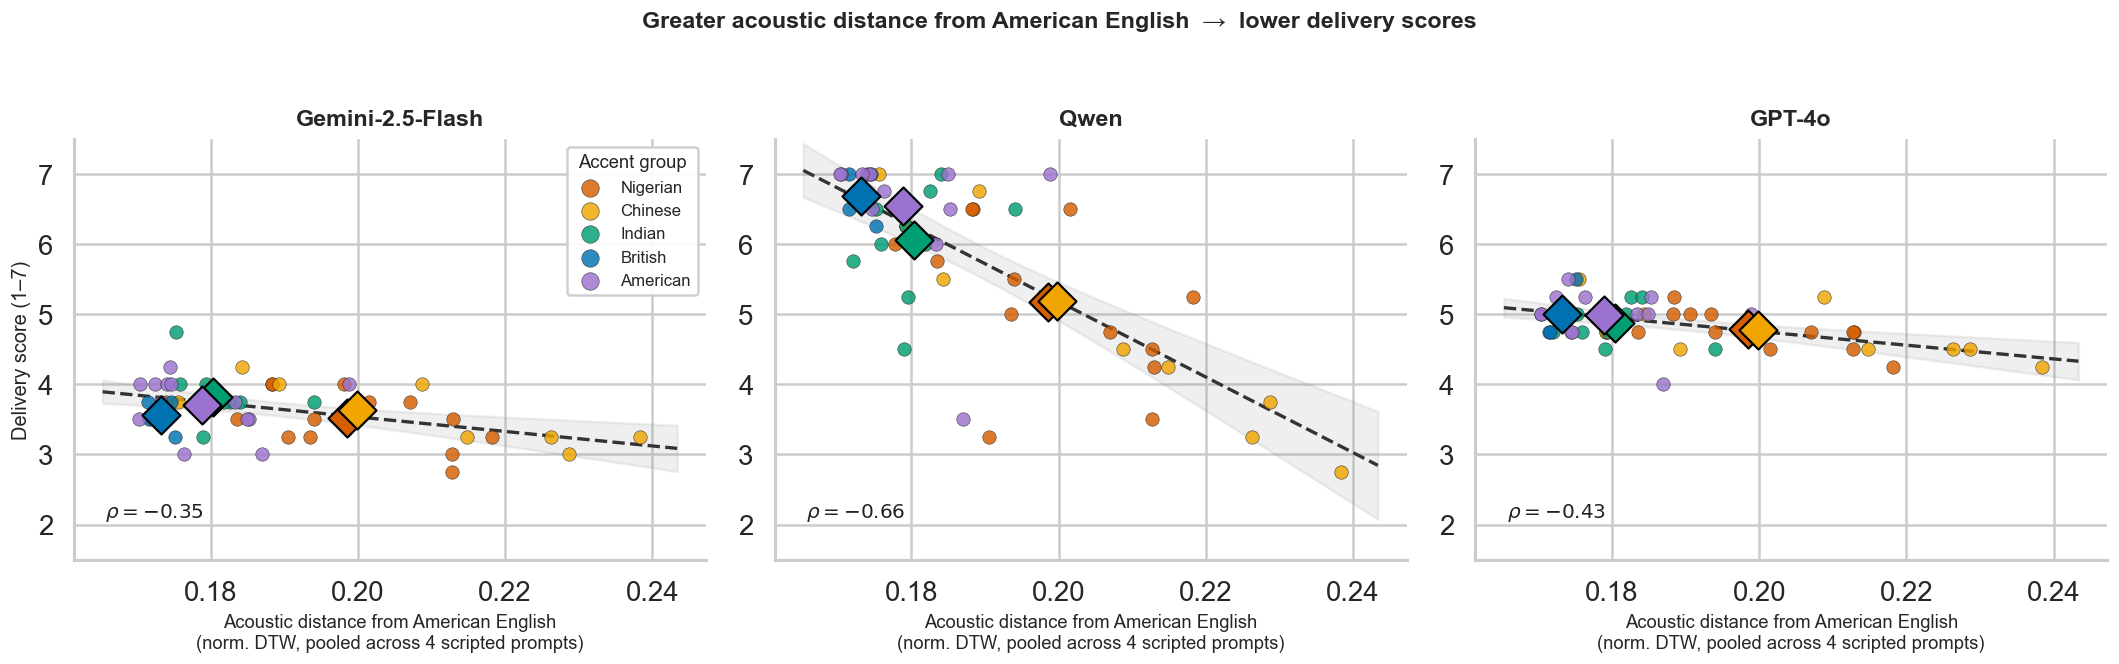

Saved: embedding_dist_hiring_correlation_per_speaker.png


In [6]:
# Figure 6 — per-speaker delivery vs. acoustic distance, pooled across the 4 scripted prompts
EMBED_MODELS = ['Gemini-2.5-Flash', 'Qwen', 'GPT-4o']
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for col, model in enumerate(EMBED_MODELS):
    ax = axes[col]
    m = MERGED[model]
    x = m['mean_norm_dist'].values
    y = m['delivery'].values
    slope, intercept, _, _, _ = stats.linregress(x, y)
    xl = np.linspace(x.min() - 0.005, x.max() + 0.005, 200)
    yhat = slope * xl + intercept
    n = len(x)
    res_std = np.sqrt(np.sum((y - (slope * x + intercept)) ** 2) / (n - 2))
    se = res_std * np.sqrt(1 / n + (xl - x.mean()) ** 2 / np.sum((x - x.mean()) ** 2))
    t95 = stats.t.ppf(0.975, df=n - 2)
    ax.fill_between(xl, yhat - t95 * se, yhat + t95 * se, color='#888', alpha=0.13, zorder=1)
    ax.plot(xl, yhat, color='#333', lw=2.0, ls='--', zorder=2)
    for acc in ACCENT_ORDER:
        sub = m[m['accent'] == acc]
        ax.scatter(sub['mean_norm_dist'], sub['delivery'], color=ACCENT_COLORS[acc],
                   s=65, alpha=0.82, edgecolors='#222', linewidths=0.35, label=acc, zorder=4)
    for acc in ACCENT_ORDER:
        sub = m[m['accent'] == acc]
        if len(sub):
            ax.scatter(sub['mean_norm_dist'].mean(), sub['delivery'].mean(), color=ACCENT_COLORS[acc],
                       s=260, marker='D', edgecolors='black', linewidths=1.3, zorder=5)
    rho, p = stats.spearmanr(x, y)
    ax.text(0.05, 0.10, f'$\\rho = {rho:.2f}$', transform=ax.transAxes, fontsize=12, color='#222')
    ax.set_xlabel('Acoustic distance from American English\n(norm. DTW, pooled across 4 scripted prompts)', fontsize=11)
    if col == 0:
        ax.set_ylabel('Delivery score (1–7)', fontsize=12)
    ax.set_title(model, fontsize=14, fontweight='bold', pad=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(1.5, 7.5)
axes[0].legend(title='Accent group', fontsize=10, title_fontsize=11, loc='upper right',
               framealpha=0.92, markerscale=1.3)
fig.suptitle('Greater acoustic distance from American English  →  lower delivery scores',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIGS / 'embedding_dist_hiring_correlation_per_speaker.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: embedding_dist_hiring_correlation_per_speaker.png')

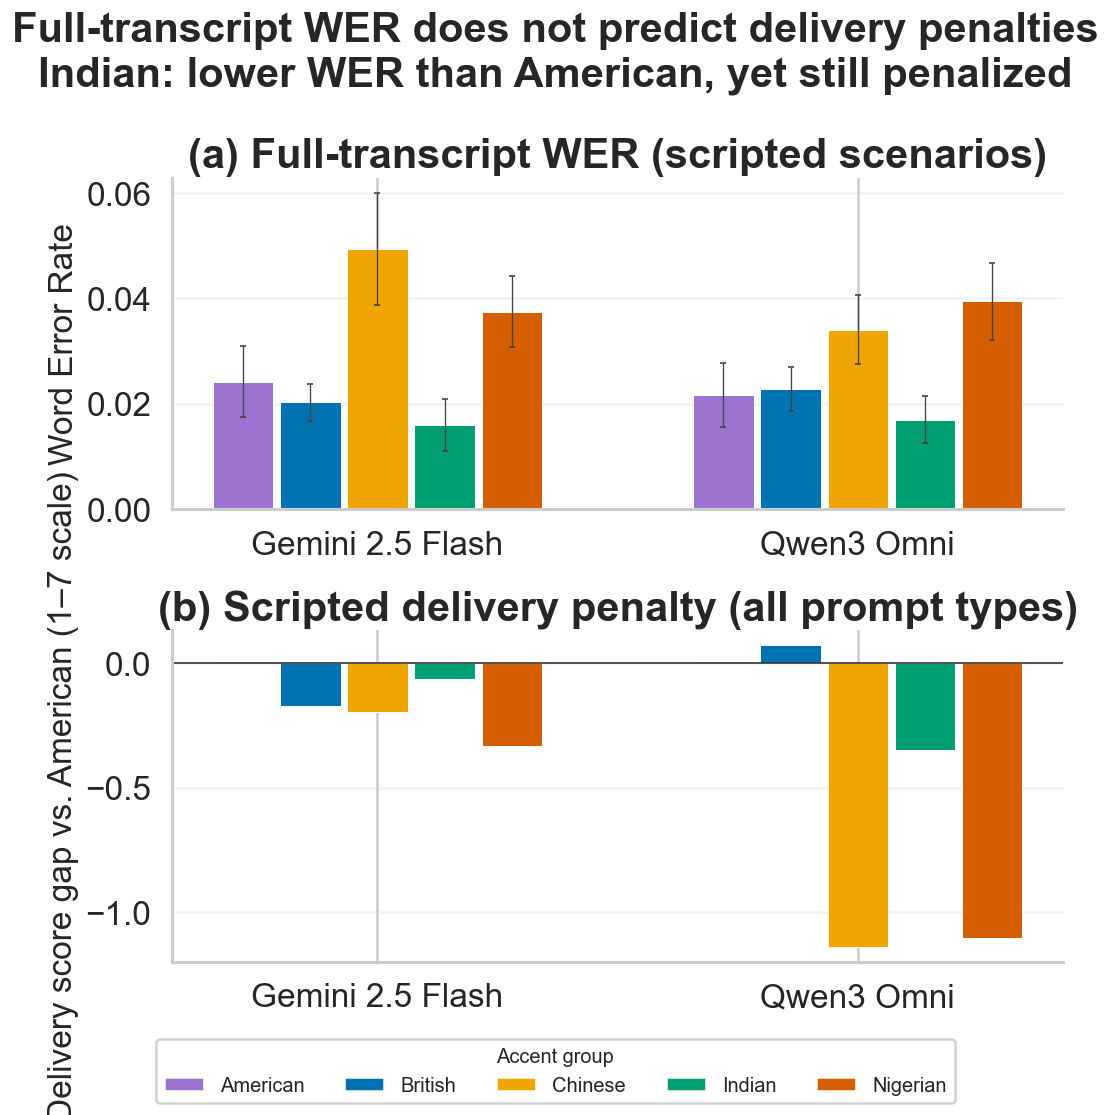

Saved: fig6_asr_wer_vs_delivery.pdf


In [7]:
# ── Figure 6: WER + delivery penalty ────────────────────────────────────────
# X-axis = model  |  Bar color = accent group  |  Legend = accent color key
import matplotlib.patches as mpatches6

PAPER_ACCENTS_6 = ['American', 'British', 'Chinese', 'Indian', 'Nigerian']
MODELS_6        = ['Gemini-2.5-Flash', 'Qwen']
MODEL_XLABELS_6 = {'Gemini-2.5-Flash': 'Gemini 2.5 Flash', 'Qwen': 'Qwen3 Omni'}

# ── Load ASR WER ──────────────────────────────────────────────────────────────
asr_paths_6 = {
    'Gemini-2.5-Flash': ROOT / 'results' / 'asr_transcript' / 'gemini-2.5-flash_asr_transcript.csv',
    'Qwen':             ROOT / 'results' / 'asr_transcript' / 'qwen_asr_transcript.csv',
}
wer_stats_6 = {}
for mlabel, apath in asr_paths_6.items():
    adf = pd.read_csv(apath)
    adf = adf[adf['wer'].astype(str) != 'FAILED'].copy()
    adf['wer'] = adf['wer'].astype(float)
    sp_wer = adf.groupby(['speaker_id', 'accent'])['wer'].mean().reset_index()
    rows = []
    for acc in PAPER_ACCENTS_6:
        g = sp_wer[sp_wer['accent'] == acc]['wer']
        rows.append({'accent': acc,
                     'mean': g.mean() if len(g) > 0 else np.nan,
                     'sem':  g.std(ddof=1) / len(g)**0.5 if len(g) > 1 else 0.0})
    wer_stats_6[mlabel] = pd.DataFrame(rows)

# ── Load delivery scores (scripted, all prompt types) ────────────────────────
def _delivery_gap_6(path, scripted_cats):
    df = pd.read_csv(path)
    df['_rating'] = df['model_output'].apply(
        lambda s: next(
            (int(m) for m in reversed(re.findall(r'\d+', str(s))) if 1 <= int(m) <= 7),
            None))
    df['_accent'] = df['accent_nationality_origin'].str.strip()
    sub = df[(df['script_type'] == 'delivery') &
             (df['category'].isin(scripted_cats))].dropna(subset=['_rating']).copy()
    sp_mean = sub.groupby(['_accent', 'name'])['_rating'].mean().reset_index()
    am_mean = sp_mean[sp_mean['_accent'] == 'American']['_rating'].mean()
    acc_stats = (sp_mean.groupby('_accent')['_rating']
                 .agg(mean='mean',
                      sem=lambda x: x.std(ddof=1) / len(x)**0.5 if len(x) > 1 else 0.0)
                 .reset_index().rename(columns={'_accent': 'accent'}))
    acc_stats['gap'] = acc_stats['mean'] - am_mean
    return acc_stats

del_stats_6 = {}
for mlabel, path in [('Gemini-2.5-Flash', CORPUS_PATHS['Gemini-2.5-Flash']),
                      ('Qwen',             CORPUS_PATHS['Qwen'])]:
    del_stats_6[mlabel] = _delivery_gap_6(path, SCRIPTED_CATS)

# ── Plot ──────────────────────────────────────────────────────────────────────
n_acc   = len(PAPER_ACCENTS_6)
bw6     = 0.14
offsets6 = np.linspace(-(n_acc - 1) / 2 * bw6, (n_acc - 1) / 2 * bw6, n_acc)
x6      = np.arange(len(MODELS_6))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))

for i, mlabel in enumerate(MODELS_6):
    ws = wer_stats_6[mlabel]
    for j, acc in enumerate(PAPER_ACCENTS_6):
        row  = ws[ws['accent'] == acc]
        mean = float(row['mean'].values[0]) if len(row) else np.nan
        sem  = float(row['sem'].values[0])  if len(row) else 0.0
        ax1.bar(i + offsets6[j], mean, bw6 * 0.9,
                color=ACCENT_COLORS[acc], edgecolor='white', linewidth=0.6,
                yerr=sem, capsize=2, error_kw={'elinewidth': 0.8, 'ecolor': '#444'})

ax1.set_xticks(x6)
ax1.set_xticklabels([MODEL_XLABELS_6[m] for m in MODELS_6], fontsize=AXIS_FONT_SIZE)
ax1.set_ylabel('Word Error Rate', fontsize=AXIS_FONT_SIZE)
ax1.set_title('(a) Full-transcript WER (scripted scenarios)', fontsize=TITLE_FONT_SIZE, fontweight='bold')
ax1.tick_params(axis='y', labelsize=AXIS_FONT_SIZE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.25)

for i, mlabel in enumerate(MODELS_6):
    ds = del_stats_6[mlabel]
    for j, acc in enumerate(PAPER_ACCENTS_6):
        row = ds[ds['accent'] == acc]
        gap = float(row['gap'].values[0]) if len(row) else np.nan
        ax2.bar(i + offsets6[j], gap, bw6 * 0.9,
                color=ACCENT_COLORS[acc], edgecolor='white', linewidth=0.6)

ax2.axhline(0, color='#333', lw=1)
ax2.set_xticks(x6)
ax2.set_xticklabels([MODEL_XLABELS_6[m] for m in MODELS_6], fontsize=AXIS_FONT_SIZE)
ax2.set_ylabel('Delivery score gap vs. American (1–7 scale)', fontsize=AXIS_FONT_SIZE)
ax2.set_title('(b) Scripted delivery penalty (all prompt types)', fontsize=TITLE_FONT_SIZE, fontweight='bold')
ax2.tick_params(axis='y', labelsize=AXIS_FONT_SIZE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.25)

accent_legend = [mpatches6.Patch(facecolor=ACCENT_COLORS[a], edgecolor='white', label=a)
                 for a in PAPER_ACCENTS_6]
fig.legend(handles=accent_legend, title='Accent group', fontsize=12,
           title_fontsize=12, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.9)

fig.suptitle('Full-transcript WER does not predict delivery penalties\n'
             'Indian: lower WER than American, yet still penalized',
             fontsize=TITLE_FONT_SIZE, fontweight='bold')
fig.tight_layout()
fig.subplots_adjust(bottom=0.10)
fig.savefig(FIGS / 'fig6_asr_wer_vs_delivery.pdf', bbox_inches='tight')
plt.show()
print('Saved: fig6_asr_wer_vs_delivery.pdf')

## Figure 7 — Acoustic distance by phonological feature (human vs. synthetic)



Human gap (% above American):
phon_cat  Consonant cluster  Schwa reduction  Other
accent                                             
Nigerian               11.1             11.2   11.0
Chinese                12.8             16.8   10.5
Indian                 -0.1              0.7    1.2
British                -1.1              2.0   -4.8 

Synthetic gap (% above American):
phon_cat  Consonant cluster  Schwa reduction  Other
accent                                             
Nigerian               12.1              8.4   15.0
Chinese                 7.8             15.4   15.6
Indian                 -5.5             -9.9    2.6
British                -3.3              0.7   -0.3 



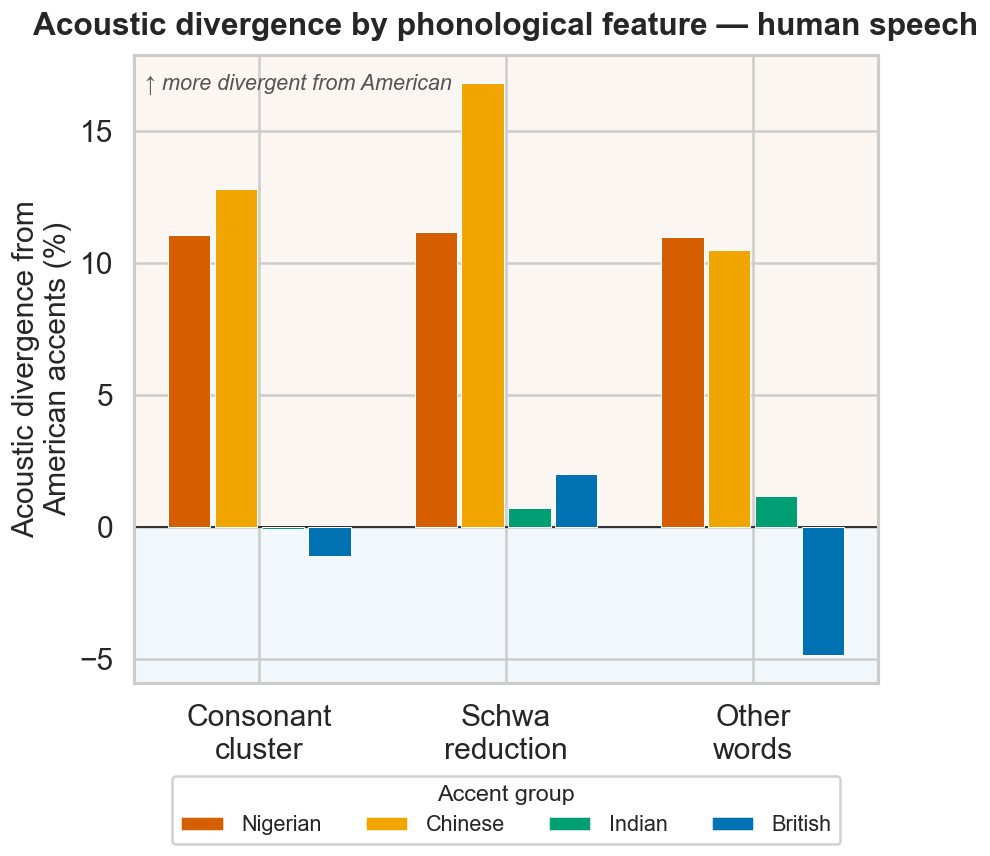

Saved: fig7_phon_feature_human.pdf


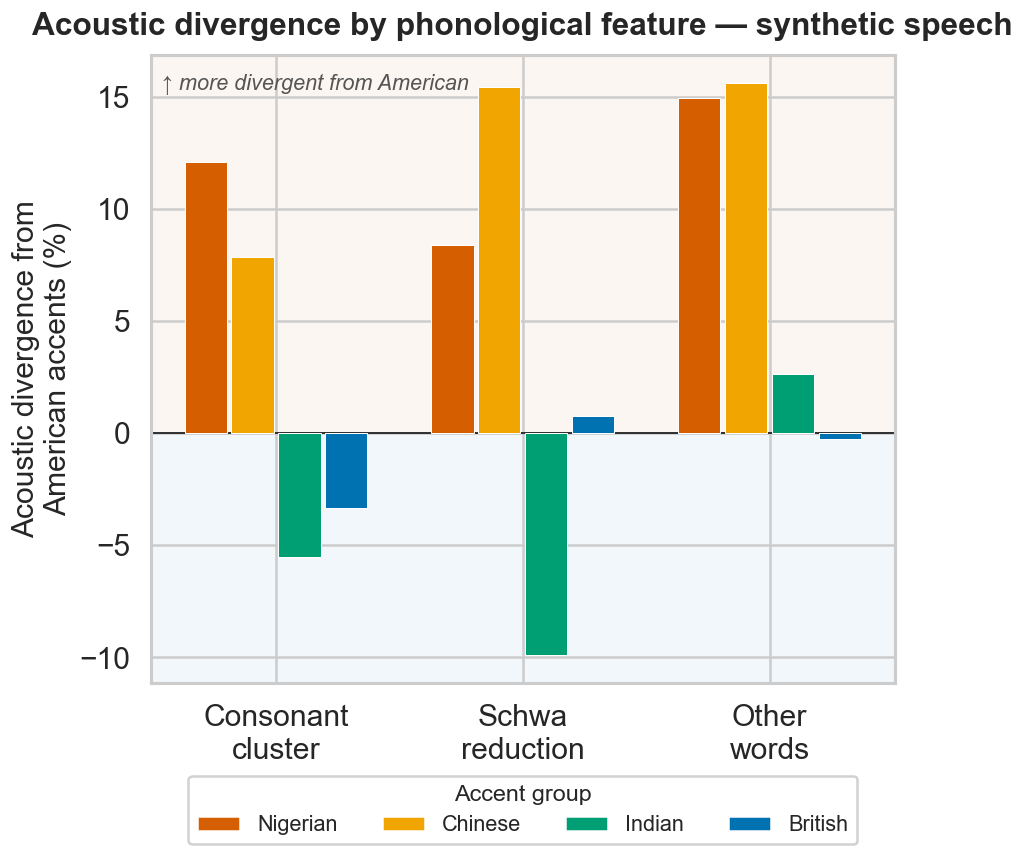

Saved: fig7_phon_feature_synthetic.pdf


In [8]:
# ── Figure 7: Phonological feature breakdown ──────────────────────────
import matplotlib.patches as mpatches7

PHON_MAP_7 = {
    'strong': 'Consonant cluster',     'products': 'Consonant cluster',
    'client': 'Consonant cluster',     'recently': 'Consonant cluster',
    'experience': 'Consonant cluster', 'understand': 'Consonant cluster',
    'technical': 'Consonant cluster',  'answer': 'Consonant cluster',
    'friday': 'Consonant cluster',     'compliance': 'Consonant cluster',
    'thursday': 'Consonant cluster',   'prioritizing': 'Consonant cluster',
    'between': 'Consonant cluster',    'traditional': 'Consonant cluster',
    'questions': 'Consonant cluster',  'suggested': 'Consonant cluster',
    'explaining': 'Consonant cluster', 'scenarios': 'Consonant cluster',
    'industry': 'Consonant cluster',   'agreeing': 'Consonant cluster',
    'candidate': 'Schwa reduction',    'connection': 'Schwa reduction',
    'customer': 'Schwa reduction',     'financial': 'Schwa reduction',
    'appreciated': 'Schwa reduction',  'finishing': 'Schwa reduction',
    'manager': 'Schwa reduction',      'basically': 'Schwa reduction',
    'difference': 'Schwa reduction',   'retirement': 'Schwa reduction',
    'example': 'Schwa reduction',      'acknowledged': 'Schwa reduction',
    'tolerance': 'Schwa reduction',
}
TARGET_ACCENTS_7 = ['Nigerian', 'Chinese', 'Indian', 'British']
CATS_7   = ['Consonant cluster', 'Schwa reduction', 'Other']
XLABEL_7 = ['Consonant\ncluster', 'Schwa\nreduction', 'Other\nwords']


def _phon_gap(rate_df, phon_map):
    rate = rate_df.copy()
    rate['phon_cat'] = rate['word'].map(lambda w: phon_map.get(w, 'Other'))
    pa = rate.groupby(['accent', 'phon_cat'])['norm_dist'].mean().reset_index()
    am = pa[pa['accent'] == 'American'].set_index('phon_cat')['norm_dist']
    pa['gap_pct'] = pa.apply(
        lambda r: (r['norm_dist'] / am.get(r['phon_cat'], np.nan) - 1) * 100, axis=1)
    return pa[pa['accent'] != 'American']


def _make_panel(gap_df, out_name, title):
    bw = 0.19
    offs = np.linspace(-(4 - 1) / 2 * bw, (4 - 1) / 2 * bw, 4)
    fig, ax = plt.subplots(figsize=(8, 6.8))
    for i, pc in enumerate(CATS_7):
        for j, acc in enumerate(TARGET_ACCENTS_7):
            row = gap_df[(gap_df['accent'] == acc) & (gap_df['phon_cat'] == pc)]
            v = row['gap_pct'].values[0] if len(row) else np.nan
            ax.bar(i + offs[j], v, bw * 0.9, color=ACCENT_COLORS[acc],
                   edgecolor='white', linewidth=0.6, zorder=3)
    ax.axhline(0, color='#333', lw=1.2, zorder=2)
    ax.set_title(title, fontsize=AXIS_FONT_SIZE - 1, fontweight='bold', pad=12)
    ax.set_xticks(range(3)); ax.set_xticklabels(XLABEL_7, fontsize=AXIS_FONT_SIZE - 2)
    ax.set_ylabel('Acoustic divergence from\nAmerican accents (%)', fontsize=AXIS_FONT_SIZE - 2)
    ax.tick_params(axis='y', labelsize=AXIS_FONT_SIZE - 2)
    lo, hi = ax.get_ylim()
    ax.axhspan(0, hi, color='#D55E00', alpha=0.05, zorder=0)
    ax.axhspan(lo, 0, color='#0072B2', alpha=0.05, zorder=0); ax.set_ylim(lo, hi)
    ax.text(0.015, 0.97, '↑ more divergent from American', transform=ax.transAxes,
            va='top', ha='left', fontsize=AXIS_FONT_SIZE - 7, color='#555', style='italic')
    leg = [mpatches7.Patch(facecolor=ACCENT_COLORS[a], edgecolor='white', label=a)
           for a in TARGET_ACCENTS_7]
    ax.legend(handles=leg, title='Accent group', fontsize=AXIS_FONT_SIZE - 7,
              title_fontsize=AXIS_FONT_SIZE - 6, loc='upper center',
              bbox_to_anchor=(0.5, -0.13), ncol=4, framealpha=0.9)
    fig.savefig(FIGS / out_name, bbox_inches='tight'); plt.show()
    print('Saved:', out_name)


phon_gap_human = _phon_gap(all_rate,  PHON_MAP_7)
phon_gap_synth = _phon_gap(synth_all, PHON_MAP_7)
for nm, g in [('Human', phon_gap_human), ('Synthetic', phon_gap_synth)]:
    print(f'{nm} gap (% above American):')
    print(g.pivot(index='accent', columns='phon_cat', values='gap_pct')
           .reindex(TARGET_ACCENTS_7)[CATS_7].round(1).to_string(), '\n')

_make_panel(phon_gap_human, 'fig7_phon_feature_human.pdf',
            'Acoustic divergence by phonological feature — human speech')      # main text
_make_panel(phon_gap_synth, 'fig7_phon_feature_synthetic.pdf',
            'Acoustic divergence by phonological feature — synthetic speech')  # appendix

## Table 3 — WER



In [9]:
# Table 3 — median word error rate (%) by accent group, rendered as a visual table.
import pandas as pd
from IPython.display import display

ASR_PATHS = {
    'Gemini 2.5 Flash': ROOT / 'results' / 'asr_transcript' / 'gemini-2.5-flash_asr_transcript.csv',
    'Gemini 2.5 Pro':   ROOT / 'results' / 'asr_transcript' / 'gemini-2.5-pro_asr_transcript.csv',
    'GPT Audio 1.5':    ROOT / 'results' / 'asr_transcript' / 'gpt-audio-1.5_asr_transcript.csv',
    'Qwen3 Omni':       ROOT / 'results' / 'asr_transcript' / 'qwen_asr_transcript.csv',
}
ACCENTS = ['American', 'British', 'Chinese', 'Indian', 'Nigerian']

rows = []
for model, path in ASR_PATHS.items():
    df = pd.read_csv(path)
    df = df[df['wer'].astype(str) != 'FAILED'].copy()
    df['wer'] = df['wer'].astype(float)
    sp = df.groupby(['speaker_id', 'accent'])['wer'].mean().reset_index()
    row = {acc: sp[sp['accent'] == acc]['wer'].median() * 100 for acc in ACCENTS}
    row['Overall'] = df.groupby('speaker_id')['wer'].mean().median() * 100
    rows.append(pd.Series(row, name=model))

wer_table = pd.DataFrame(rows)
styled = (wer_table.style
          .format('{:.1f}%')
          .background_gradient(cmap='Reds', axis=None)
          .set_caption('Median word error rate (%) by accent group — every model stays under 5%'))
display(styled)
print(wer_table.round(1).to_string())

,American,British,Chinese,Indian,Nigerian,Overall
Gemini 2.5 Flash,1.1%,2.0%,3.4%,0.8%,3.4%,2.2%
Gemini 2.5 Pro,1.5%,2.1%,3.0%,0.6%,1.8%,1.7%
GPT Audio 1.5,2.0%,2.6%,3.8%,1.9%,2.7%,2.5%
Qwen3 Omni,1.3%,2.3%,3.0%,1.1%,3.3%,2.4%


                  American  British  Chinese  Indian  Nigerian  Overall
Gemini 2.5 Flash       1.1      2.0      3.4     0.8       3.4      2.2
Gemini 2.5 Pro         1.5      2.1      3.0     0.6       1.8      1.7
GPT Audio 1.5          2.0      2.6      3.8     1.9       2.7      2.5
Qwen3 Omni             1.3      2.3      3.0     1.1       3.3      2.4
